# Scheduled economic events: what do markets do around them?

Three US announcements arrive on a published schedule and are watched by every market:

| event | what it is | how often |
|---|---|---|
| Fed interest rate decision | the central bank sets its interest rate | 8 times a year |
| Jobs report | new jobs and the unemployment rate | monthly |
| Inflation report | consumer prices | monthly |

The tempting idea is "predict which way the market goes on these days". This notebook
tests that idea honestly, on Bitcoin, gold, and US stocks.

**One thing must be said first.** A market moves on the gap between the number and
what was *expected*. Nobody knows that gap beforehand, and the data of what was
expected is sold, not free. So everything here uses only **dates and prices**. It can
show how markets have behaved *around* these days. It cannot show how they react to a
surprise.

**The rules were written down before any result was computed**
(`docs/DECISIONS.md`, entry 055, committed on its own first). Five questions:

1. Does the market move more on the day?
2. Does it lean one way the day before?
3. Does it lean one way on the day?
4. Does the day's move carry on the next day?
5. Does it carry on over the next week?

Rebuild with `uv run python backend/scripts/build_notebooks.py 10_events`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.analytics import events
from radar.db.session import make_engine, session_scope
from radar.pipelines import events as job
from radar.pipelines.signals import daily_close
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
pd.set_option("display.width", 220)
engine, universe = make_engine(), get_universe()
NAMES = {"BTC/USD": "Bitcoin", "GLD": "Gold", "SPY": "US stocks"}
COLOURS = {"BTC/USD": "tab:orange", "GLD": "goldenrod", "SPY": "tab:blue"}

kinds = list(events.get_events())
with session_scope(engine) as session:
    closes = {a.symbol: daily_close(session, a) for a in universe.primary}
    stored = job.build(session, universe, kinds)
for kind in kinds:
    print(f"{kind.name}: {len(kind.dates)} dates, {kind.dates[0]} to {kind.dates[-1]}  ({kind.source})")

Fed interest rate decision: 95 dates, 2016-01-27 to 2027-12-08  (Federal Reserve, FOMC meeting calendars)
US jobs report: 131 dates, 2016-01-08 to 2026-12-04  (Bureau of Labor Statistics, release schedule)
US inflation report: 131 dates, 2016-01-20 to 2026-12-10  (Bureau of Labor Statistics, release schedule)


## 1. The dates

The dates come from the official pages of the Federal Reserve and the Bureau of Labor
Statistics, taken once and stored in a file. Only **scheduled** events are used:
emergency Fed meetings are left out, because the point is events you can see coming.

Each dot below is one event.

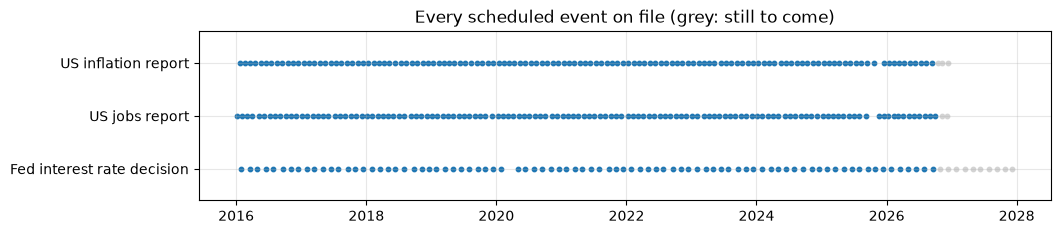

In [2]:
fig, ax = plt.subplots(figsize=(11, 2.2))
for row, kind in enumerate(kinds):
    days = pd.to_datetime(kind.dates)
    past = days <= pd.Timestamp.now()
    ax.scatter(days[past], [row] * past.sum(), s=10, color="tab:blue")
    ax.scatter(days[~past], [row] * (~past).sum(), s=10, color="lightgrey")
ax.set_yticks(range(len(kinds)), [k.name for k in kinds])
ax.set(title="Every scheduled event on file (grey: still to come)", ylim=(-0.6, len(kinds) - 0.4));

## 2. Question 1: does the market move more on the day?

Compare the size of the move on event days (close to close, whichever direction) with
the size on every other day.

In [3]:
rows = []
for result in stored.results:
    for m in result.markets:
        rows.append(
            {
                "event": result.name,
                "market": NAMES[m.symbol],
                "past events": m.n_events,
                "typical move on the day %": m.size.on_event * 100,
                "on any other day %": m.size.other_days * 100,
                "ratio": m.size.on_event / m.size.other_days,
                "verdict": m.size.verdict,
            }
        )
size_table = pd.DataFrame(rows)
size_table

,event,market,past events,typical move on the day %,on any other day %,ratio,verdict
0,Fed interest rate decision,Bitcoin,46,2.379,2.038,1.167,no measurable difference
1,Fed interest rate decision,Gold,85,0.920,0.729,1.261,moves more on these days
2,Fed interest rate decision,US stocks,85,0.772,0.721,1.071,no measurable difference
3,US jobs report,Bitcoin,69,2.142,2.043,1.048,no measurable difference
4,US jobs report,Gold,126,0.816,0.731,1.116,no measurable difference
5,US jobs report,US stocks,126,0.869,0.715,1.215,moves more on these days
6,US inflation report,Bitcoin,68,2.686,2.024,1.327,no measurable difference
7,US inflation report,Gold,126,0.734,0.736,0.997,no measurable difference
8,US inflation report,US stocks,126,0.775,0.720,1.077,no measurable difference


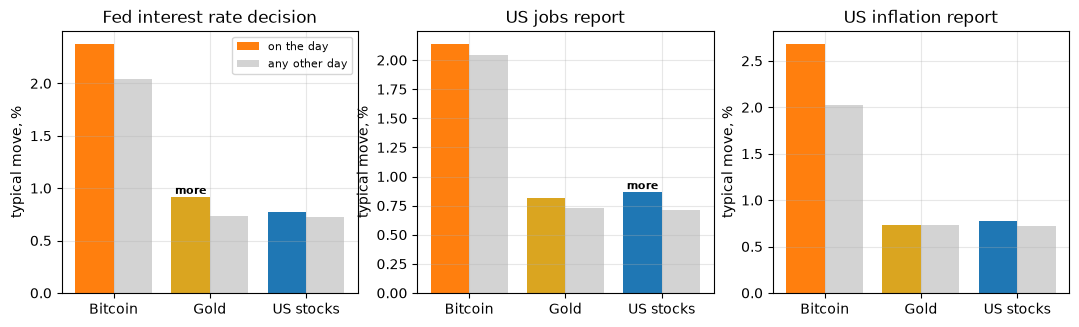

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=False)
for ax, result in zip(axes, stored.results):
    labels = [NAMES[m.symbol] for m in result.markets]
    on = [m.size.on_event * 100 for m in result.markets]
    off = [m.size.other_days * 100 for m in result.markets]
    x = np.arange(len(labels))
    ax.bar(x - 0.2, on, width=0.4, color=[COLOURS[m.symbol] for m in result.markets], label="on the day")
    ax.bar(x + 0.2, off, width=0.4, color="lightgrey", label="any other day")
    for i, m in enumerate(result.markets):
        if m.size.verdict == "moves more on these days":
            ax.text(i - 0.2, on[i], "more", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x, labels)
    ax.set(title=result.name, ylabel="typical move, %")
axes[0].legend(fontsize=8);

Bars marked "more" are the cases that still stand out after allowing for nine
comparisons being made at once. Read the table above for which they are: the finding
is specific to a market and an event, not general.

A caution on what "moves more" does and does not mean. The difference is in the
**size** of the day's move. It says nothing about which way.

## 3. Questions 2 to 5: is there a direction?

For each event and market, four shares are measured and compared with the same share
on any day:

- how often the **day before** ended higher,
- how often the **day itself** ended higher,
- how often the **next day** went the same way as the event day,
- how often the **next week** went the same way as the event day.

In the chart, the dot is the share around events, the bar is the range that share
could plausibly lie in, and the black tick is the share on any day. **A bar that
covers its tick means no pattern.**

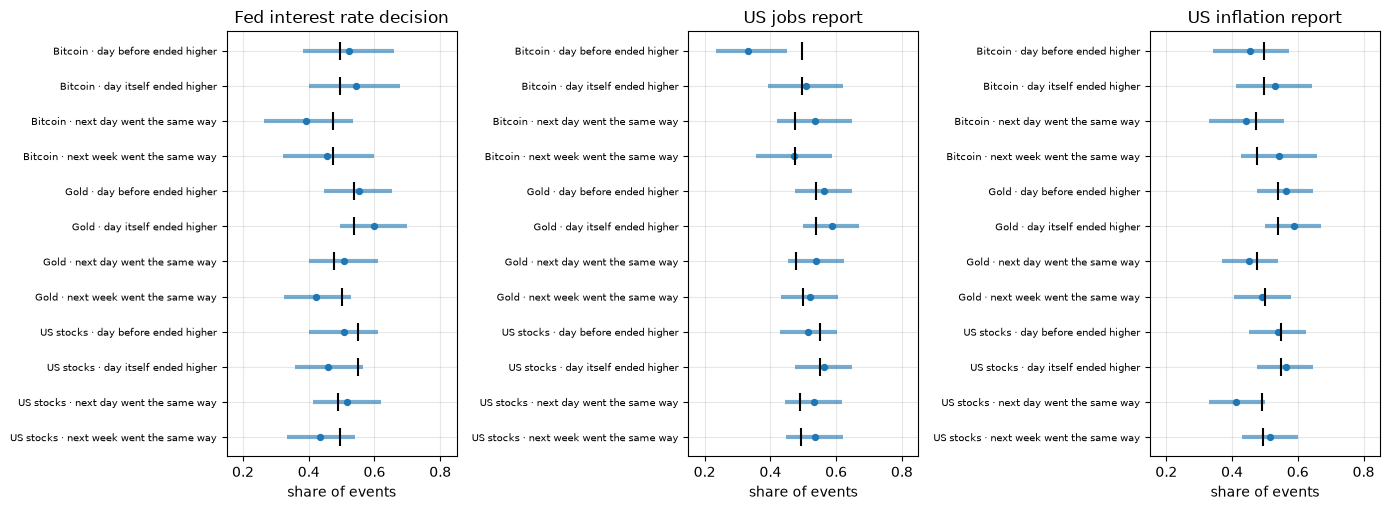

In [5]:
QUESTIONS = [("day_before", "day before ended higher"), ("event_day", "day itself ended higher"),
             ("next_day", "next day went the same way"), ("next_week", "next week went the same way")]
rows = []
for result in stored.results:
    for m in result.markets:
        for field, label in QUESTIONS:
            s = getattr(m, field)
            rows.append({"event": result.name, "market": NAMES[m.symbol], "question": label, "events": s.n,
                         "share": s.share, "low": s.low, "high": s.high, "any day": s.baseline,
                         "p": s.p_value, "verdict": s.verdict})
direction = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharex=True)
for ax, (name, part) in zip(axes, direction.groupby("event", sort=False)):
    part = part.reset_index(drop=True)
    y = np.arange(len(part))
    ax.hlines(y, part["low"], part["high"], color="tab:blue", linewidth=3, alpha=0.6)
    ax.scatter(part["share"], y, color="tab:blue", zorder=3, s=18)
    ax.scatter(part["any day"], y, marker="|", color="black", s=160, zorder=4)
    ax.set_yticks(y, part["market"] + " · " + part["question"], fontsize=7)
    ax.invert_yaxis()
    ax.set(title=name, xlim=(0.15, 0.85), xlabel="share of events")
fig.tight_layout()

In [6]:
tested = direction[direction["events"] >= events.MIN_EVENTS]
raw = int((tested["p"] < 0.05).sum())
kept = int((~tested["verdict"].isin(["no measurable pattern", "not enough events"])).sum())
print(f"{len(tested)} comparisons of direction had enough events.")
print(f"{raw} looked special at the usual 5% bar; {kept} remain after allowing for {len(tested)} being looked at together.")
print(f"By luck alone, about {len(tested) * 0.05:.0f} would be expected to look special.")
direction.sort_values("p").head(6)[["event", "market", "question", "events", "share", "any day", "p", "verdict"]]

36 comparisons of direction had enough events.
1 looked special at the usual 5% bar; 0 remain after allowing for 36 being looked at together.
By luck alone, about 2 would be expected to look special.


,event,market,question,events,share,any day,p,verdict
12,US jobs report,Bitcoin,day before ended higher,69,0.333,0.496,0.008,no measurable pattern
34,US inflation report,US stocks,next day went the same way,126,0.413,0.490,0.090,no measurable pattern
9,Fed interest rate decision,US stocks,day itself ended higher,85,0.459,0.550,0.102,no measurable pattern
7,Fed interest rate decision,Gold,next week went the same way,85,0.424,0.500,0.160,no measurable pattern
18,US jobs report,Gold,next day went the same way,126,0.540,0.477,0.181,no measurable pattern
27,US inflation report,Bitcoin,next week went the same way,68,0.544,0.475,0.276,no measurable pattern


**No pattern in direction.** The cell above shows how many comparisons looked special
on their own and how many survive once all of them are considered together, beside
how many luck alone would produce. The closest calls are listed so they can be judged
for what they are.

This is the honest answer to "can RADAR predict direction around these events from
dates and prices?": **no**. Not before the event, not on the day, and not after it.

## 4. Why this is the expected answer

- The date of an event is known to everyone months ahead. If markets reliably rose the
  day before a Fed decision, traders would buy two days before, and the pattern would
  move and then vanish. A pattern that anyone can see on a calendar does not last.
- What moves the price on the day is the **surprise**, and by definition a surprise is
  as likely to be one way as the other.
- What *can* persist is the size of the move: an event day is a day when new
  information arrives, so a larger move is natural, and knowing that in advance does
  not let anyone profit from it.

## 5. What RADAR does with this

- Shows a **calendar** of what is coming, in your local time.
- Shows, for each event and market, the **typical size of the move** on the day beside
  any other day, and says where the difference is real.
- Shows the direction tests with their answer, **"no pattern"**, and does not offer a
  direction forecast for events. Offering one would be making something up.

## What this cannot tell you

- Anything about a **surprise**. With the expected figures, one could ask "after a
  higher-than-expected inflation number, what happened?", which is a different and
  better question. RADAR does not have that data.
- Anything within the day. Moves are measured close to close; the first minutes after
  a release are not looked at.
- Anything about unscheduled events, which are left out on purpose.